# Model Evaluation

**Owner:** Manuela  
**Model:** MobileNetV2  
**Goal:** Load the saved model, run all test images through it, and report accuracy, precision, recall, F1, and a confusion matrix.

---
### What this notebook does
1. Loads the saved MobileNetV2 model file (.pt)
2. Runs all test images through it
3. Compares predictions vs actual breeds
4. Reports 4 metrics and plots a confusion matrix
5. Written summary of findings

## 1. Upload Dataset

We upload the dataset zip file directly into Colab. The archive contains the train, valid, and test folders for all 69 dog breed classes. This step is required every time a new Colab session starts since Colab does not persist files between sessions.

In [1]:
from google.colab import files
files.upload()

Saving archive.zip to archive.zip


## 2. Unzip Dataset

Once uploaded, we extract the zip file into a folder called `dog-breed-classification`. This gives us access to the `test` folder which contains the images the model will be graded on. We print the folder contents to confirm the extraction was successful.

In [2]:
import zipfile, os

with zipfile.ZipFile('/content/archive.zip', 'r') as z:
    z.extractall('/content/dog-breed-classification/')

print(os.listdir('/content/dog-breed-classification'))

['train', 'valid', 'dogs.csv', 'test']


## 3. Upload Saved Model

Here we upload the saved MobileNetV2 model file provided by Ozor. This `.pt` file contains everything the model learned during training — it went through two phases where it was gradually taught to recognize dog breeds, starting with basic features and then fine tuning on the full dataset. Without this file there is nothing to evaluate.

In [3]:
from google.colab import files
uploaded = files.upload()
print('Upload complete!')
print('Uploaded files:', list(uploaded.keys()))

Saving mobilenet_v2_dogbreed_regularized.pt to mobilenet_v2_dogbreed_regularized.pt
Upload complete!
Uploaded files: ['mobilenet_v2_dogbreed_regularized.pt']


## 4. Imports

We import all the libraries needed for evaluation. PyTorch and torchvision are used to load and run the model. scikit-learn provides the functions that calculate our four metrics and build the confusion matrix. seaborn and matplotlib are used to visualize the confusion matrix as a heatmap.

In [4]:
import torch
import torchvision.models as models
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print('All libraries imported successfully.')

All libraries imported successfully.


## 5. Configuration

We define the key settings for evaluation. The model path points to Ozor's saved `.pt` file. The test folder points to the images that were saved separately and never shown to the model during training, so we can fairly grade how well it performs on brand new images. We set `NUM_CLASSES` to 69 to match the number of breeds the model was trained on. The device is set to GPU if available, otherwise CPU.

In [5]:
MODEL_PATH  = '/content/mobilenet_v2_dogbreed_regularized.pt'
TEST_ROOT   = '/content/dog-breed-classification/test'
NUM_CLASSES = 69
BATCH_SIZE  = 32
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Using device: {DEVICE}')
print(f'Model path:   {MODEL_PATH}')
print(f'Test folder:  {TEST_ROOT}')

Using device: cpu
Model path:   /content/mobilenet_v2_dogbreed_regularized.pt
Test folder:  /content/dog-breed-classification/test


## 6. Verify Test Folder

Before we start loading images we first check that the test folder is actually there and has the right number of breed folders inside it. This is just a quick check to make sure everything is in the right place before we run the rest of the notebook.

In [6]:
print('Contents of /content/dog-breed-classification:')
print(os.listdir('/content/dog-breed-classification'))
print(f'\nNumber of breed folders in test: {len(os.listdir(TEST_ROOT))}')

Contents of /content/dog-breed-classification:
['train', 'valid', 'dogs.csv', 'test']

Number of breed folders in test: 70


## 7. Build Test DataLoader

We scan the test folder and collect all image file paths along with their breed labels. The evaluation transforms resize every image to 224x224 and apply ImageNet normalization the exact same preprocessing used during training. No augmentation is applied here since we want consistent results. We exclude Coyote from the class list since it was not included in the training data, leaving us with 69 breeds to evaluate.

In [7]:
eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std= [0.229, 0.224, 0.225]
    ),
])

# Build class list from test folder but EXCLUDE Coyote (not in training set)
all_test_breeds = sorted([
    d for d in os.listdir(TEST_ROOT)
    if os.path.isdir(os.path.join(TEST_ROOT, d))
])
class_names = [b for b in all_test_breeds if b != "Coyote"]

label2idx = {breed: idx for idx, breed in enumerate(class_names)}

filepaths  = []
labels_raw = []

for breed in class_names:
    folder = os.path.join(TEST_ROOT, breed)
    for fname in os.listdir(folder):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            filepaths.append(os.path.join(folder, fname))
            labels_raw.append(breed)

print(f'Breeds found:      {len(class_names)}')
print(f'Total test images: {len(filepaths)}')

Breeds found:      69
Total test images: 690


## 8. Custom Dataset Class

We create a custom class that opens each image and connects it to the correct breed label. This gets passed into a DataLoader which groups the images into batches of 32 so they can be fed into the model efficiently. We print a quick check at the end to confirm the images are loading correctly before we move on.

In [8]:
class DogTestDataset(Dataset):
    def __init__(self, filepaths, labels_raw, label2idx, transform=None):
        self.filepaths  = filepaths
        self.labels_raw = labels_raw
        self.label2idx  = label2idx
        self.transform  = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img   = Image.open(self.filepaths[idx]).convert('RGB')
        label = self.label2idx[self.labels_raw[idx]]
        if self.transform:
            img = self.transform(img)
        return img, label

test_dataset = DogTestDataset(filepaths, labels_raw, label2idx, transform=eval_transforms)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

sample_imgs, sample_labels = next(iter(test_loader))
print(f'Batch image shape: {sample_imgs.shape}')
print(f'Batch label shape: {sample_labels.shape}')
print('Test DataLoader ready.')

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])
Test DataLoader ready.


## 9. Load the Saved Model

We set up the MobileNetV2 model to match exactly how Ozor built it during training. If the setup does not match perfectly the model will not load correctly. We then load all of Ozor's saved weights into the model so it has everything it learned during training. Finally we switch the model into evaluation mode which tells it we are only testing, not training, so it behaves consistently for every prediction.

In [9]:
model = models.mobilenet_v2(pretrained=False)
model.classifier[1] = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.last_channel, NUM_CLASSES)
)

model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

print('MobileNetV2 model loaded successfully.')

MobileNetV2 model loaded successfully.


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


## 10. Run Inference on the Test Set

We go through every test image and run it through the model. For each image the model gives a score to all 69 breeds and we pick whichever breed scored the highest as the prediction. We keep track of two lists — what the model predicted and what the correct answer actually was. These two lists are what we use to calculate our metrics in the next step.

In [10]:
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels_batch in test_loader:
        images       = images.to(DEVICE)
        labels_batch = labels_batch.to(DEVICE)

        outputs      = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels_batch.cpu().numpy())

print(f'Done! Evaluated {len(all_labels)} test images.')

Done! Evaluated 690 test images.


## 11. Evaluation Metrics

We calculate the four evaluation metrics using scikit-learn:
- **Accuracy** — the percentage of all test images the model predicted correctly
- **Precision** — when the model predicted a specific breed, how often it was actually that breed
- **Recall** — out of all images of a specific breed, how many the model correctly identified
- **F1 Score** — a single number that balances precision and recall, useful when both matter equally

We use weighted averaging so that breeds with more test images have proportionally more influence on the final score.

In [11]:
accuracy  = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall    = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1        = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print('=' * 50)
print('      MOBILENETV2 EVALUATION RESULTS')
print('=' * 50)
print(f'  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)')
print(f'  Precision : {precision:.4f}  ({precision*100:.2f}%)')
print(f'  Recall    : {recall:.4f}  ({recall*100:.2f}%)')
print(f'  F1 Score  : {f1:.4f}  ({f1*100:.2f}%)')
print('=' * 50)

      MOBILENETV2 EVALUATION RESULTS
  Accuracy  : 0.9507  (95.07%)
  Precision : 0.9578  (95.78%)
  Recall    : 0.9507  (95.07%)
  F1 Score  : 0.9474  (94.74%)


## 12. Per-Breed Breakdown

We print a full classification report showing precision, recall, and F1 individually for every one of the 69 breeds. This lets us identify which specific breeds the model performed best and worst on, rather than only seeing the overall averages from the previous cell.

In [12]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    zero_division=0
))

                   precision    recall  f1-score   support

           Afghan       1.00      1.00      1.00        10
 African Wild Dog       1.00      1.00      1.00        10
         Airedale       1.00      1.00      1.00        10
American Hairless       0.90      0.90      0.90        10
 American Spaniel       1.00      0.80      0.89        10
          Basenji       1.00      1.00      1.00        10
           Basset       1.00      0.90      0.95        10
           Beagle       1.00      1.00      1.00        10
   Bearded Collie       1.00      1.00      1.00        10
         Bermaise       1.00      1.00      1.00        10
     Bichon Frise       1.00      1.00      1.00        10
         Blenheim       1.00      1.00      1.00        10
       Bloodhound       1.00      1.00      1.00        10
         Bluetick       1.00      1.00      1.00        10
    Border Collie       1.00      1.00      1.00        10
           Borzoi       1.00      1.00      1.00       

## 13. Confusion Matrix

We plot a 69x69 confusion matrix as a heatmap. Each row represents the actual breed and each column represents what the model predicted. The diagonal shows correct predictions — a bright diagonal indicates strong performance. Any off-diagonal values represent misclassifications, showing which breeds were confused with each other. The matrix is saved to the outputs folder for use in the final report.

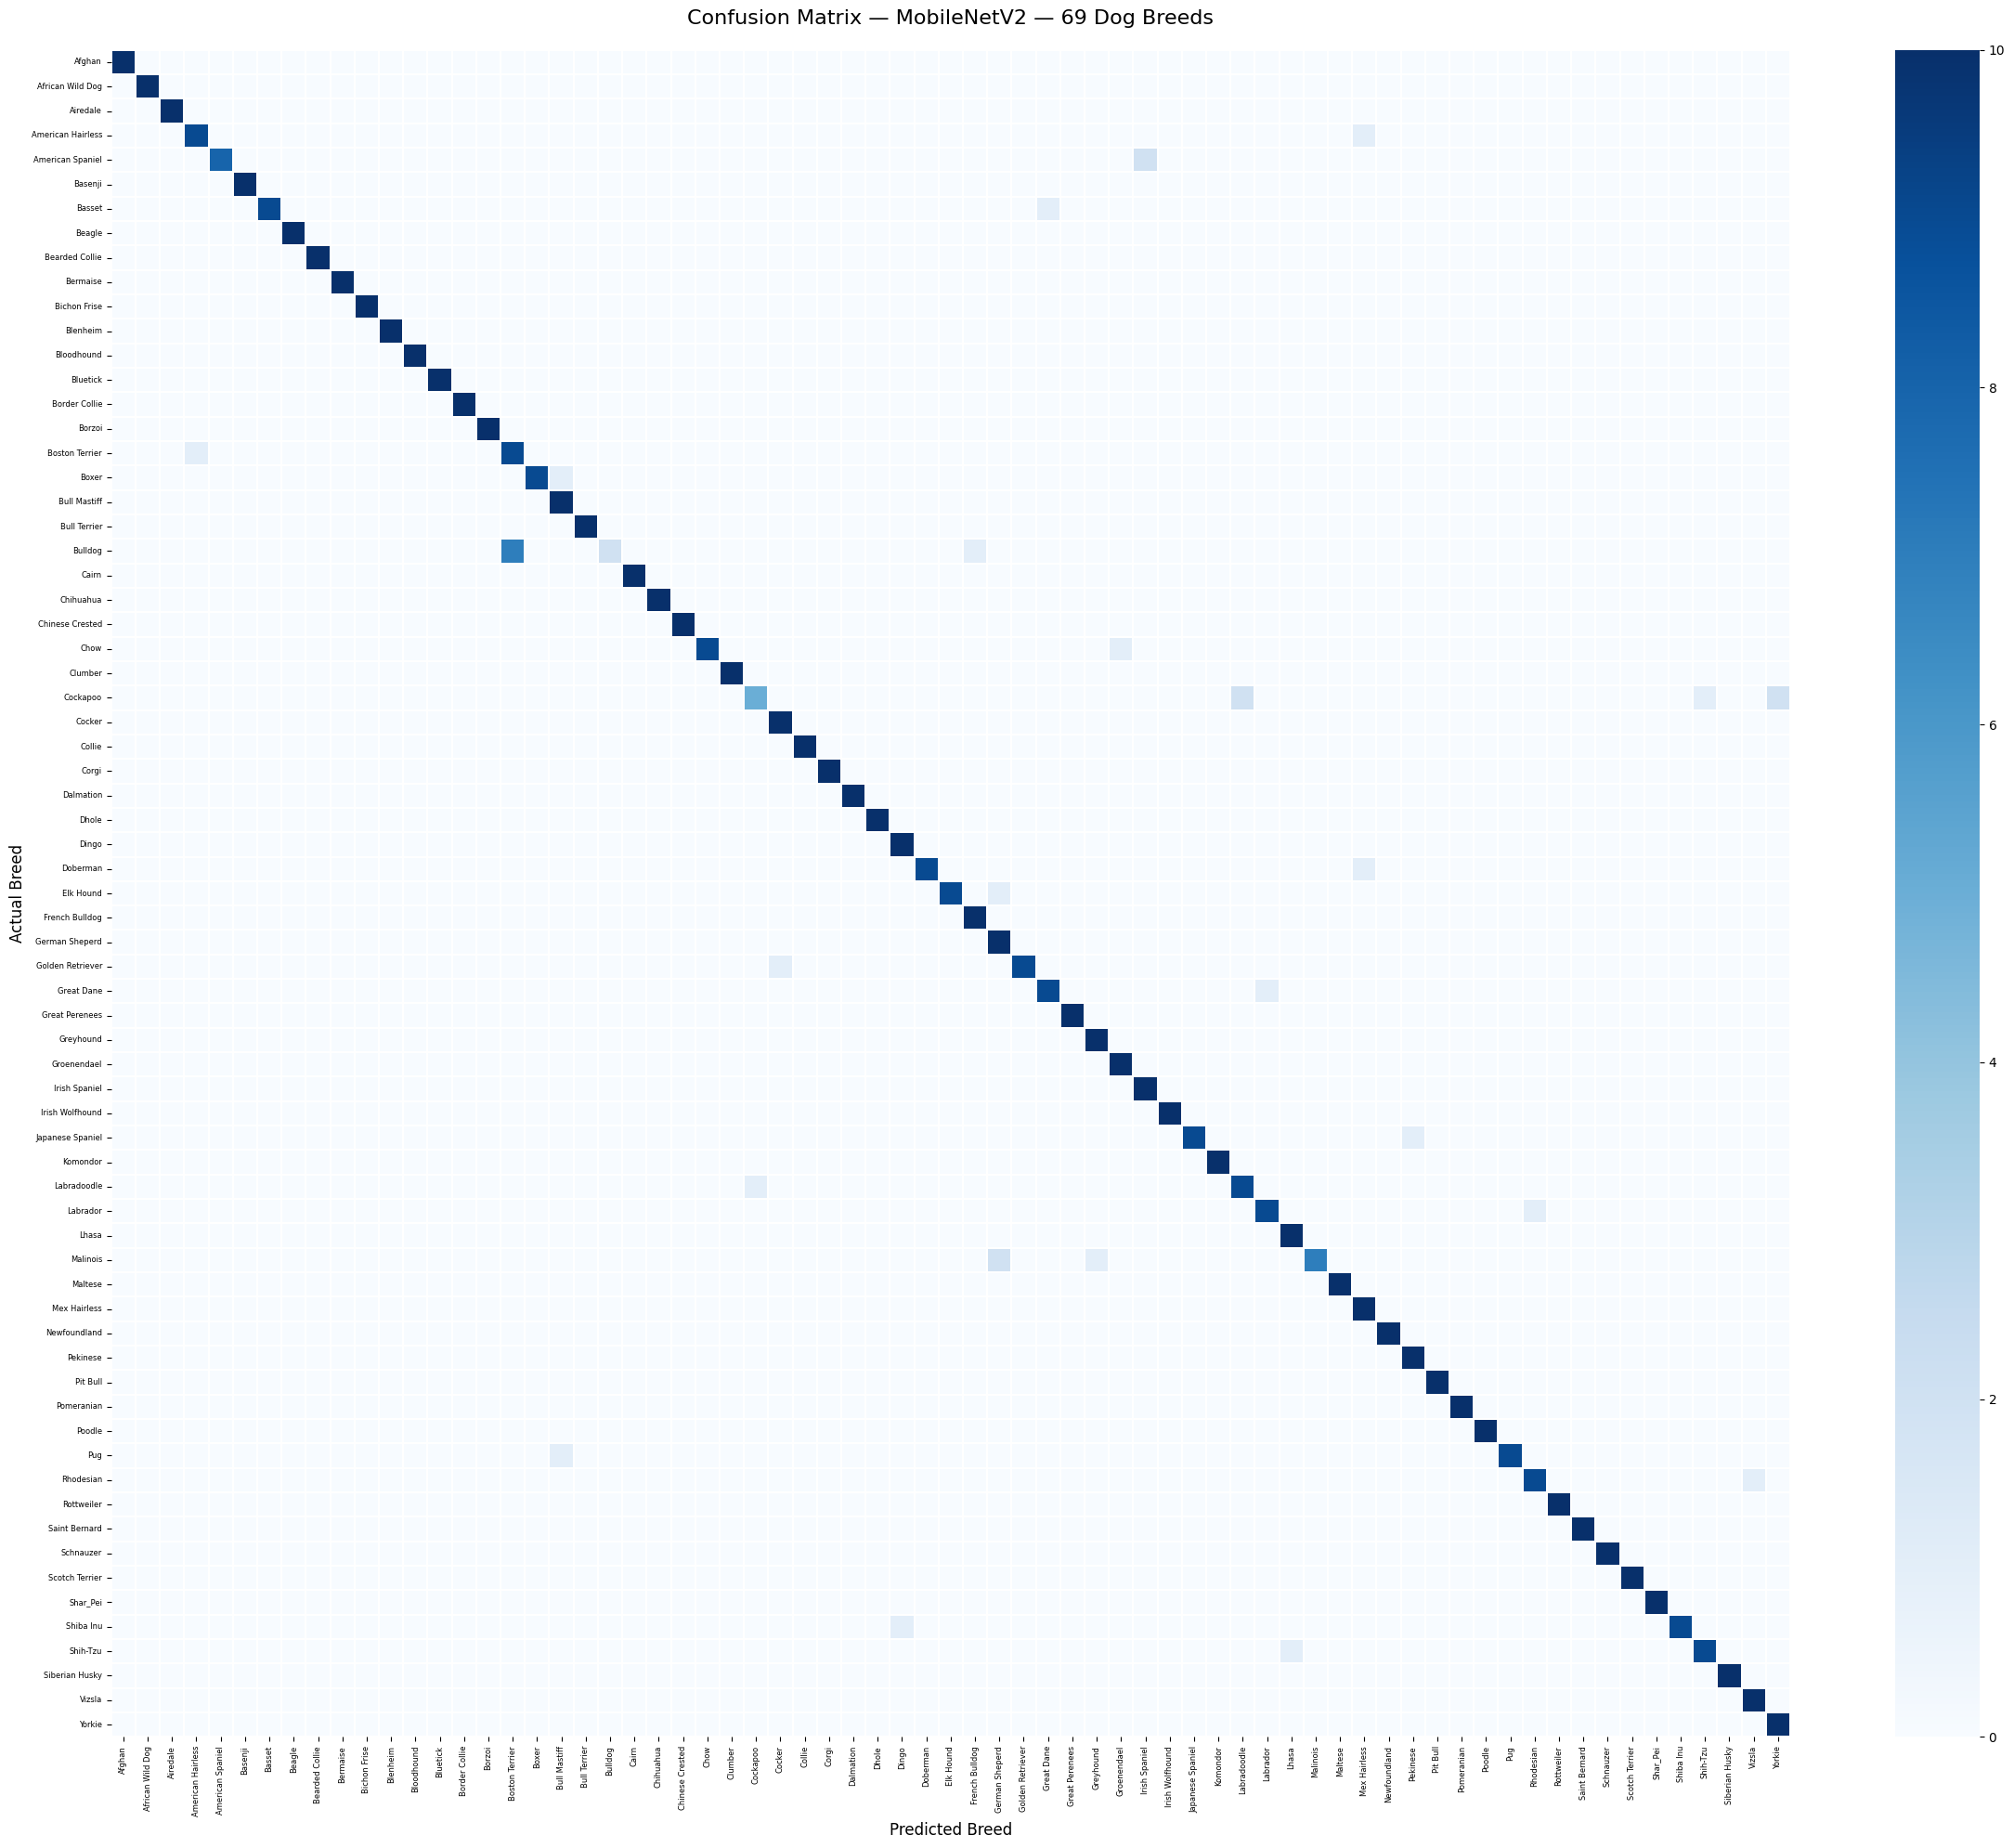

Confusion matrix saved to /content/outputs/confusion_matrix_mobilenetv2.png


In [13]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(24, 20))
sns.heatmap(
    cm,
    annot=False,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.3
)
plt.title('Confusion Matrix — MobileNetV2 — 69 Dog Breeds', fontsize=16, pad=20)
plt.xlabel('Predicted Breed', fontsize=12)
plt.ylabel('Actual Breed', fontsize=12)
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()
os.makedirs('/content/outputs', exist_ok=True)
plt.savefig('/content/outputs/confusion_matrix_mobilenetv2.png', dpi=150)
plt.show()
print('Confusion matrix saved to /content/outputs/confusion_matrix_mobilenetv2.png')

## 14. Top 10 Most Common Mistakes

We zero out the diagonal of the confusion matrix so only mistakes remain, then find the 10 most frequent misclassifications. This tells us exactly which breed pairs the model struggled to tell apart, which is useful for understanding where the model's weaknesses lie and why.

In [14]:
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

flat_indices = np.argsort(cm_no_diag.ravel())[::-1][:10]
rows, cols   = np.unravel_index(flat_indices, cm_no_diag.shape)

print('Top 10 Most Common Misclassifications:')
print(f'{"Actual Breed":<35} {"Predicted As":<35} {"Count"}')
print('-' * 75)
for r, c in zip(rows, cols):
    if cm_no_diag[r, c] > 0:
        print(f'{class_names[r]:<35} {class_names[c]:<35} {cm_no_diag[r, c]}')

Top 10 Most Common Misclassifications:
Actual Breed                        Predicted As                        Count
---------------------------------------------------------------------------
Bulldog                             Boston Terrier                      7
Cockapoo                            Yorkie                              2
Malinois                            German Sheperd                      2
American Spaniel                    Irish Spaniel                       2
Cockapoo                            Labradoodle                         2
Malinois                            Greyhound                           1
Doberman                            Mex Hairless                        1
American Hairless                   Mex Hairless                        1
Golden Retriever                    Cocker                              1
Pug                                 Bull Mastiff                        1


## 15. Best and Worst Performing Breeds

We calculate per breed accuracy by dividing each breed's correct predictions by its total test images. We then sort all 69 breeds from worst to best, printing the 10 lowest and 10 highest performing breeds. This highlights which classes were most challenging for the model and which were classified with near perfect accuracy.

In [15]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)
breed_acc     = sorted(zip(class_names, per_class_acc), key=lambda x: x[1])

print('10 WORST Performing Breeds:')
print(f'{"Breed":<35} {"Accuracy"}')
print('-' * 50)
for breed, acc in breed_acc[:10]:
    print(f'{breed:<35} {acc:.2%}')

print('\n10 BEST Performing Breeds:')
print(f'{"Breed":<35} {"Accuracy"}')
print('-' * 50)
for breed, acc in breed_acc[-10:][::-1]:
    print(f'{breed:<35} {acc:.2%}')

10 WORST Performing Breeds:
Breed                               Accuracy
--------------------------------------------------
Bulldog                             20.00%
Cockapoo                            50.00%
Malinois                            70.00%
American Spaniel                    80.00%
American Hairless                   90.00%
Basset                              90.00%
Boston Terrier                      90.00%
Boxer                               90.00%
Chow                                90.00%
Doberman                            90.00%

10 BEST Performing Breeds:
Breed                               Accuracy
--------------------------------------------------
Yorkie                              100.00%
Vizsla                              100.00%
Siberian Husky                      100.00%
Shar_Pei                            100.00%
Scotch Terrier                      100.00%
Schnauzer                           100.00%
Saint Bernard                       100.00%
Rottweiler    

## 16. Written Summary

The MobileNetV2 model was tested on 69 dog breeds using 690 images it had never seen before. Out of all the test images it got **95.07%** of them correct. The precision was **95.78%**, the recall was **95.07%**, and the F1 score was **94.74%**. All four numbers are close to each other which means the model performed consistently across nearly all breeds.

Looking at the confusion matrix, almost all the correct answers line up along the diagonal which means the model did a great job overall. The biggest struggle was with **Bulldog**, which only got **20%** accuracy the model confused it with Boston Terrier 7 out of 10 times. This makes sense because Bulldogs and Boston Terriers share a similar face shape and body size. Other breeds that had some difficulty were **Cockapoo** at 50% and **Malinois** at 70%, which were mostly confused with Yorkie and German Shepherd respectively due to their similar coat and body shape.

On the other hand, 10 breeds including **Yorkie, Vizsla, Siberian Husky, Schnauzer, Poodle** and others were classified with **100% accuracy**, showing the model learned those breeds very well. Compared to the ResNet50 model which scored 97.51% accuracy, MobileNetV2 scored slightly lower which is expected since ResNet50 is a bigger and more powerful model. However 95.07% is still strong performance, and MobileNetV2 remains a practical choice for shelters that do not have powerful computer hardware.